In [27]:
# Import necessary libraries;
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score
from torch import nn
import torch
warnings.filterwarnings('ignore')


In [28]:
# Load the dataset;
data = pd.read_csv("email_classification_svm.csv")

# Information about the dataset;
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [29]:
# Describe the dataset;
print(data.describe().T)

                            count      mean       std       min       25%  \
subject_formality_score    1000.0 -1.009046  0.654219 -3.532770 -1.252867   
sender_relationship_score  1000.0 -0.006300  1.059501 -2.218219 -1.006076   
email_type                 1000.0  0.498000  0.500246  0.000000  0.000000   

                                50%       75%       max  
subject_formality_score   -0.994760 -0.754839  2.180933  
sender_relationship_score  0.439233  0.994943  1.699497  
email_type                 0.000000  1.000000  1.000000  


In [30]:
# Unique values in the dataset;
print(data.nunique())

subject_formality_score      1000
sender_relationship_score    1000
email_type                      2
dtype: int64


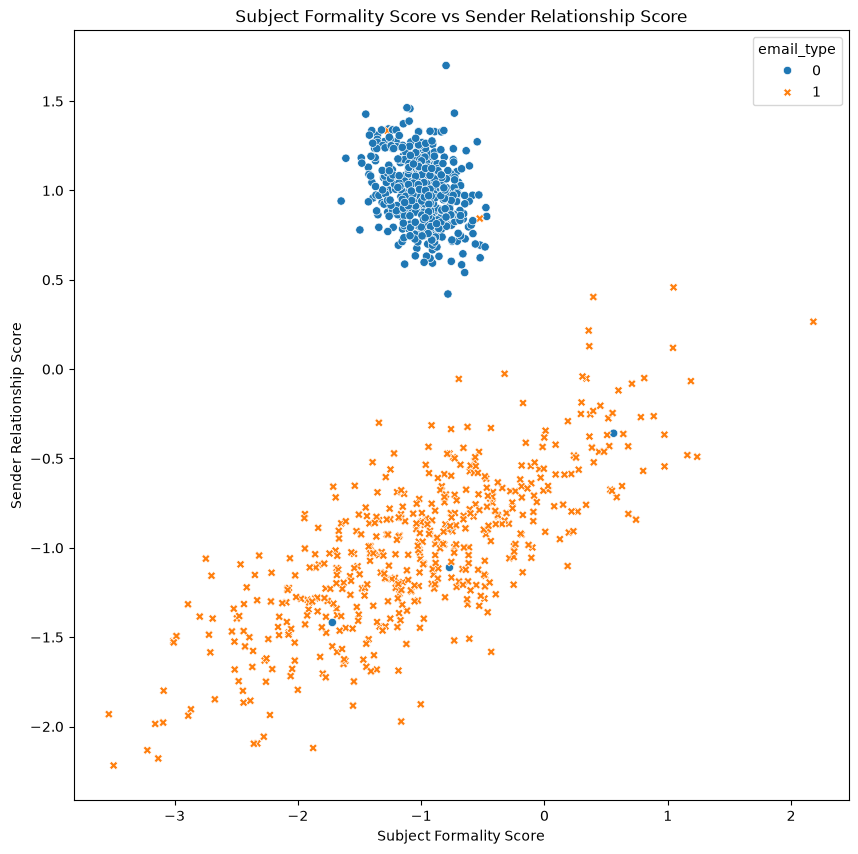

In [31]:
# Visualize the dataset;
plt.figure(figsize=(10, 10))
sns.scatterplot(x=data['subject_formality_score'], y=data['sender_relationship_score'], hue=data['email_type'], style=data['email_type'])
plt.title('Subject Formality Score vs Sender Relationship Score')
plt.xlabel('Subject Formality Score')
plt.ylabel('Sender Relationship Score')
plt.show()

In [32]:
## Prepare the data;
X = data[['subject_formality_score','sender_relationship_score']].values
y = data['email_type'].values

print(X.shape, y.shape)

# Split the dataset into training and testing sets;
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(len(X_train), len(X_test), len(y_train), len(y_test))

(1000, 2) (1000,)
800 200 800 200


In [33]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Shape (100,) -> (100, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1) # Shape (100,) -> (100, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

print(X_train.ndim, y_train.ndim) # Dimesions of X_train and y_train variables. They are 2 because we have 2 features, if we have 1 feature, we would have been to add "unsqueeze(1)" to the tensor.

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])
2 2


In [34]:
## Build a classification model;
class ClassficationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer1 = nn.Linear(in_features=2, out_features=5)
        self.linear_layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.linear_layer2(self.linear_layer1(x))

model_0 = ClassficationModel()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [35]:
def calculate_accuracy(y_test,y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    
    return accuracy

In [39]:
torch.manual_seed(42)
epoch_count = 100

for epoch in range(epoch_count):
    model_0.train()
    y_logits = model_0(X_train)
    y_preds = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_train, y_preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test, test_preds)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss.item()}, Accuracy: {acc}, Test Loss: {test_loss.item()}, Test Accuracy: {test_acc}")
            

Epoch: 0, Loss: 0.4707314670085907, Accuracy: 95.5, Test Loss: 0.45825281739234924, Test Accuracy: 94.5
Epoch: 10, Loss: 0.4507271945476532, Accuracy: 96.5, Test Loss: 0.4379098415374756, Test Accuracy: 95.0
Epoch: 20, Loss: 0.4314098656177521, Accuracy: 97.375, Test Loss: 0.41831108927726746, Test Accuracy: 95.0
Epoch: 30, Loss: 0.4127829670906067, Accuracy: 97.875, Test Loss: 0.3994579315185547, Test Accuracy: 95.0
Epoch: 40, Loss: 0.39485615491867065, Accuracy: 98.0, Test Loss: 0.3813570737838745, Test Accuracy: 95.5
Epoch: 50, Loss: 0.3776414096355438, Accuracy: 98.125, Test Loss: 0.3640168309211731, Test Accuracy: 96.0
Epoch: 60, Loss: 0.36115023493766785, Accuracy: 98.25, Test Loss: 0.3474441468715668, Test Accuracy: 96.5
Epoch: 70, Loss: 0.34539154171943665, Accuracy: 98.375, Test Loss: 0.33164268732070923, Test Accuracy: 96.5
Epoch: 80, Loss: 0.330369770526886, Accuracy: 98.375, Test Loss: 0.31661152839660645, Test Accuracy: 97.0
Epoch: 90, Loss: 0.3160844147205353, Accuracy: 9

In [ ]:
## Plot the decision boundary;
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # Total Effective Weight = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.linear_layer1.weight.detach().numpy()       # shape (5,2)
    b1 = model.linear_layer1.bias.detach().numpy()         # shape (5,)
    W2 = model.linear_layer2.weight.detach().numpy()       # shape (1,5)
    b2 = model.linear_layer2.bias.detach().numpy()[0]      # shape (1,)

    # Effective W and b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # two features's weight

    # Effective b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X range
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Calculate x2 from the equation of the line
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Points
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

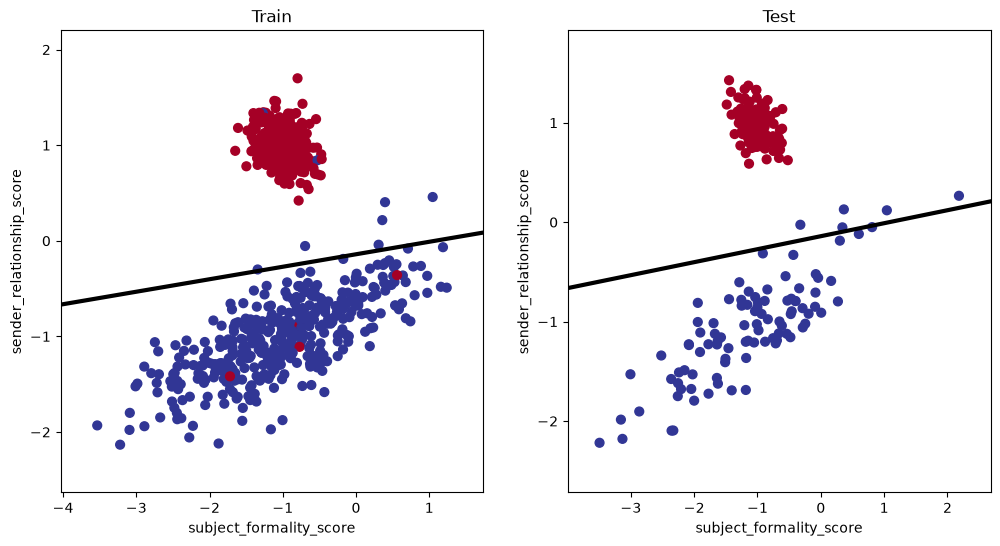

In [41]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()